# Detecting iris - pipeline

In [21]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pixel_transformations import binarize_avg

Loading the image

In [22]:
path = "/Users/lila/BiometriaProjekt1/BiometriaProjekt1/bryanl1.bmp"
img = Image.open(path).convert("RGB")
original_image = np.array(img)

In [23]:
import matplotlib.pyplot as plt

def show_images(images, titles=None):
    n = len(images)
    # squeeze=False ensures 'axes' is always a 2D array, even if n=1
    fig, axes = plt.subplots(1, n, figsize=(n * 5, 5), squeeze=False)
    
    for i in range(n):
        axes[0, i].imshow(images[i])
        if titles: 
            axes[0, i].set_title(titles[i])
        axes[0, i].axis('off')
        
    plt.tight_layout()
    plt.show()


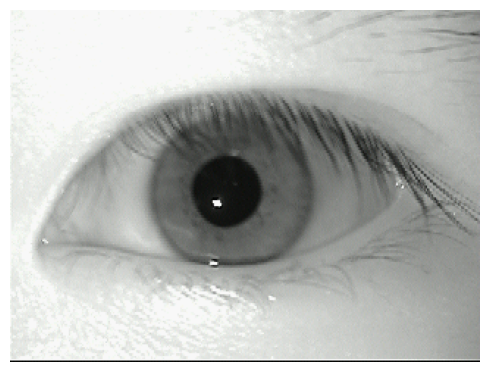

In [24]:
show_images([original_image])

Obliczenie średniej jasności obrazu

In [25]:
average_brightness = np.mean(original_image)
print(f"Średnia jasność obrazu: {average_brightness}")

Średnia jasność obrazu: 178.69557291666666


Binaryzacja dla źrenicy

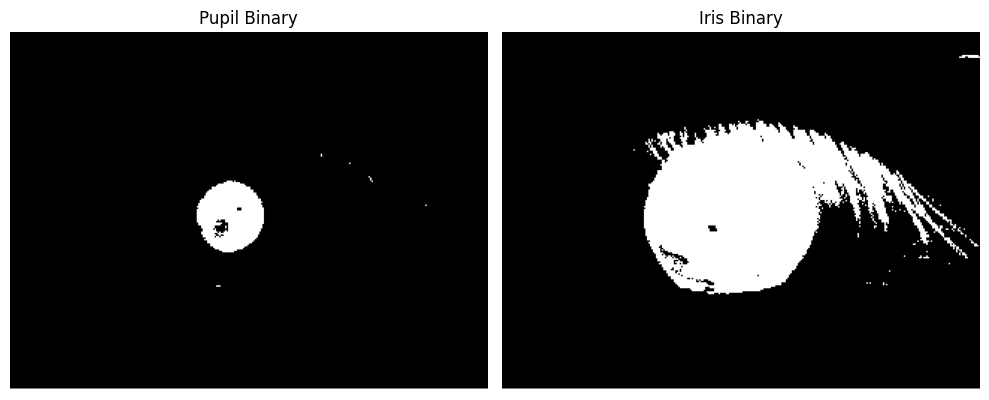

In [26]:
pupil_bin  = binarize_avg(original_image, x=6.2, invert=True)  # źrenica biała
iris_bin   = binarize_avg(original_image, x=1.5, invert=True)  # tęczówka biała
show_images([pupil_bin, iris_bin], titles=["Pupil Binary", "Iris Binary"])

**Zastosowanie operacji morfologiznych dla źrenicy:**
- otwarcie - pozbycie się pozostałych punktów
- zamknięcie - wypełnienie dziur

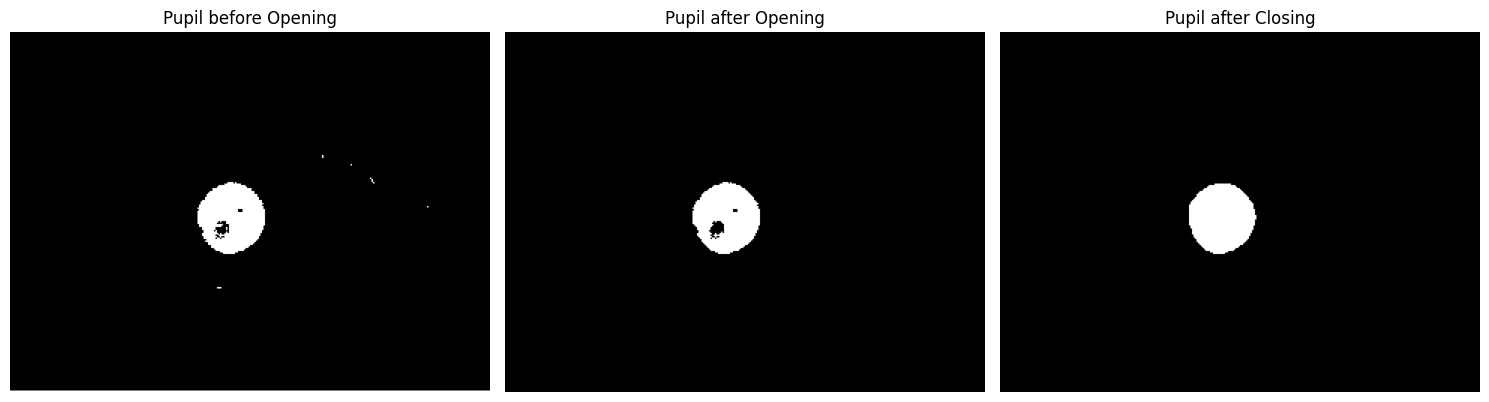

In [27]:
from morphological import opening, closing


pupil_opening = opening(pupil_bin, kernel_size=3, shape='circle')
pupil = closing(pupil_opening, kernel_size=20, shape='circle')
show_images([pupil_bin, pupil_opening, pupil], titles=["Pupil before Opening", "Pupil after Opening", "Pupil after Closing"])

Obliczenie środka źrenicy (zakładamy, że źrenica i tęczówka są współśrodkowe)

In [28]:
print(pupil.shape)

(240, 320, 3)


In [29]:
def get_center_and_radius(pupil):
    pupil_2d = pupil[:, :, 0]
    
    proj_vertical   = np.sum(pupil_2d, axis=0)
    proj_horizontal = np.sum(pupil_2d, axis=1)
    
    # środek przez środek masy
    indices_x = np.arange(len(proj_vertical))
    indices_y = np.arange(len(proj_horizontal))
    cx = int(np.sum(indices_x * proj_vertical) / np.sum(proj_vertical))
    cy = int(np.sum(indices_y * proj_horizontal) / np.sum(proj_horizontal))
    
    # promień = odległość od pierwszego do ostatniego białego piksela
    cols_nonzero = np.where(proj_vertical > 0)[0]
    rx = (cols_nonzero[-1] - cols_nonzero[0]) / 2

    rows_nonzero = np.where(proj_horizontal > 0)[0]
    ry = (rows_nonzero[-1] - rows_nonzero[0]) / 2

    radius = int((rx + ry) / 2)
    
    print(f"Środek: ({cx}, {cy}), Promień: {radius}")
    return (cx, cy, radius)
cx, cy, pupil_radius = get_center_and_radius(pupil)

Środek: (147, 123), Promień: 22


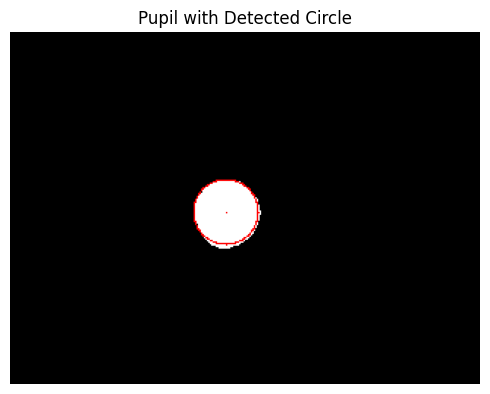

In [30]:
def draw_img_with_circle(image, cx, cy, radius):
    img_with_circle = image.copy()
    img_with_circle[cy, cx] = [255, 0, 0]  # zaznacz środek
    for angle in range(0, 360, 1):
        x = int(cx + radius * np.cos(np.radians(angle)))
        y = int(cy + radius * np.sin(np.radians(angle)))
        if 0 <= x < img_with_circle.shape[1] and 0 <= y < img_with_circle.shape[0]:
            img_with_circle[y, x] = [255, 0, 0] 
    return img_with_circle
pupil_with_radius_and_center = draw_img_with_circle(pupil, cx, cy, pupil_radius)
show_images([pupil_with_radius_and_center], titles=["Pupil with Detected Circle"])

**Zastosowanie operacji morfologiznych dla tęczówki:**
- otwarcie - pozbycie się pozostałych rzęs
- zamknięcie - wypełnienie dziur


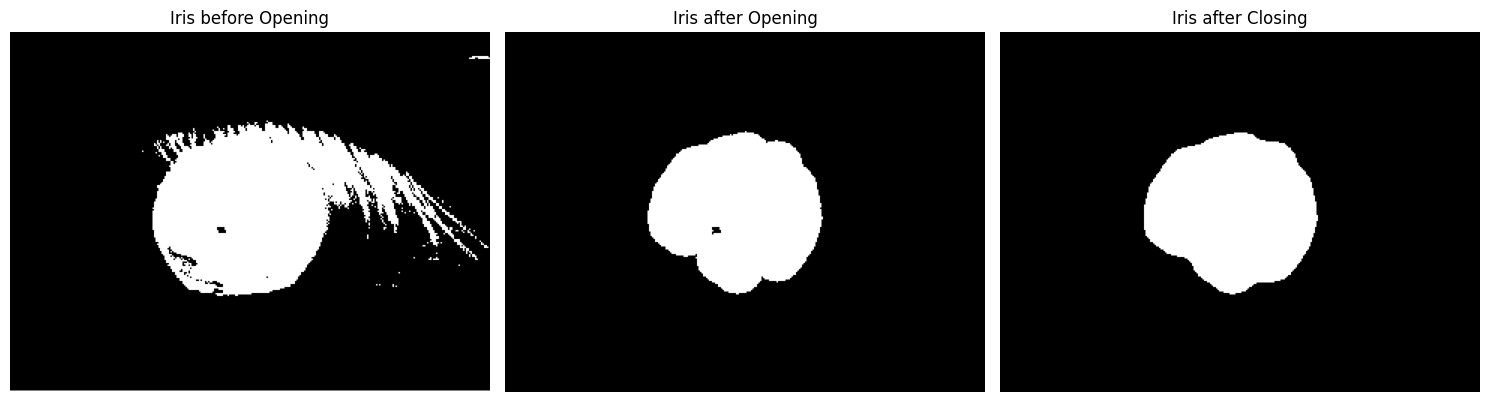

In [31]:
from morphological import opening, closing


iris_bin_opening = opening(iris_bin, kernel_size=35, shape='circle')
iris = closing(iris_bin_opening, kernel_size=20, shape='circle')
show_images([iris_bin, iris_bin_opening, iris], titles=["Iris before Opening", "Iris after Opening", "Iris after Closing"])

Środek: (155, 118), Promień: 55


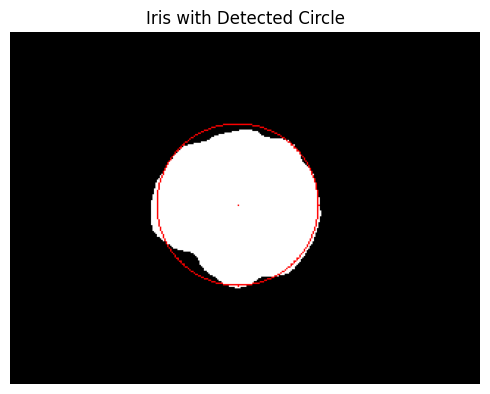

In [32]:
cx_iris, cy_iris, iris_radius = get_center_and_radius(iris)
iris_with_radius_and_center = draw_img_with_circle(iris, cx_iris, cy_iris, iris_radius)
show_images([iris_with_radius_and_center], titles=["Iris with Detected Circle"])

In [33]:
def apply_iris_mask(img, iris_mask_2d, pupil_mask_2d):
    # pierścień = tęczówka MINUS źrenica
    ring_mask = np.where(iris_mask_2d == 255, 1, 0) - \
                np.where(pupil_mask_2d == 255, 1, 0)
    ring_mask = np.clip(ring_mask, 0, 1)  # usuń ewentualne -1
    
    # zastosuj maskę na oryginalnym obrazie
    # ring_mask musi być 3D żeby mnożyć przez RGB
    ring_mask_3d = np.stack([ring_mask, ring_mask, ring_mask], axis=-1)
    result = (img * ring_mask_3d).astype(np.uint8)
    
    return result

In [34]:
iris_region = apply_iris_mask(original_image, iris[:, :, 0], pupil[:, :, 0])
outside_region = apply_iris_mask(original_image, 255 - iris[:, :, 0], pupil[:, :, 0])
eye_with_radius_and_center = draw_img_with_circle(original_image, cx, cy, pupil_radius)
eye_with_radius_and_center = draw_img_with_circle(eye_with_radius_and_center, cx, cy, iris_radius)


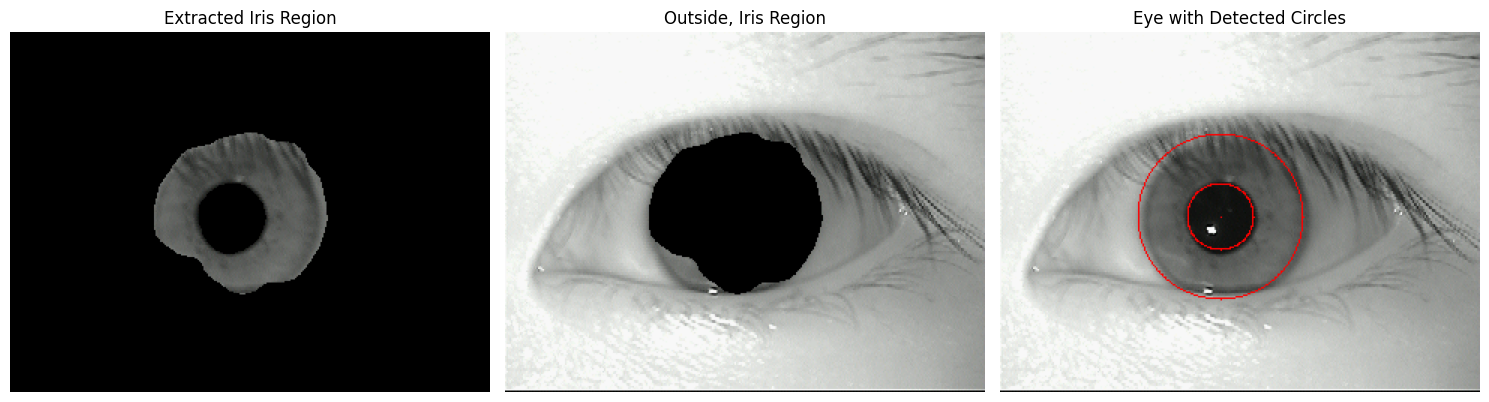

In [35]:
show_images([iris_region, outside_region, eye_with_radius_and_center], titles=["Extracted Iris Region", "Outside, Iris Region", "Eye with Detected Circles"])

In [36]:
def unwrap_iris(img, cx, cy, r_inner, r_outer, num_angles=360, num_radii=64):
    """
    cx, cy      - środek źrenicy (już masz)
    r_inner     - promień źrenicy (już masz)
    r_outer     - promień tęczówki (musisz wyznaczyć)
    num_angles  - szerokość prostokąta (kolumny)
    num_radii   - wysokość prostokąta (wiersze = pasy radialne)
    """
    h, w = img.shape[:2]
    result = np.zeros((num_radii, num_angles, 3), dtype=np.uint8)
    
    angles = np.linspace(0, 2 * np.pi, num_angles)
    radii  = np.linspace(r_inner, r_outer, num_radii)
    
    for i, r in enumerate(radii):
        for j, theta in enumerate(angles):
            # biegunowe → kartezjańskie
            x = int(cx + r * np.cos(theta))
            y = int(cy + r * np.sin(theta))
            
            # sprawdź czy piksel jest w obrazie
            if 0 <= x < w and 0 <= y < h:
                result[i, j] = img[y, x]
    
    return result

unwrapped = unwrap_iris(original_image, cx, cy, pupil_radius, iris_radius)

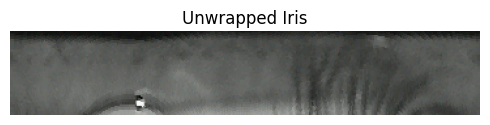

In [37]:
show_images([unwrapped], titles=["Unwrapped Iris"])

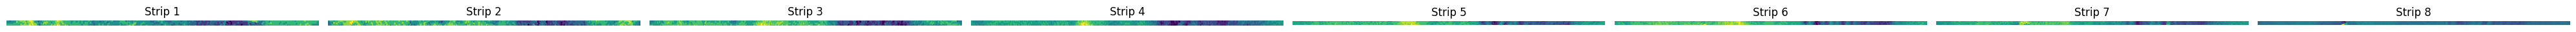

In [38]:
strips = np.array_split(unwrapped[10:54, :, 0], 8, axis=0)  # 8 pasów
show_images([strip for strip in strips], titles=[f"Strip {i+1}" for i in range(8)])

In [39]:
# każdy pas → wektor 1D o długości 128
strip_1d = []
for strip in strips:
    # uśrednij w kierunku radialnym (axis=0)
    avg = np.mean(strip, axis=0)          # (num_angles,)
    # próbkuj do 128 punktów
    indices = np.linspace(0, len(avg)-1, 128).astype(int)
    strip_1d.append(avg[indices])         # (128,)